In [ ]:
## This is a script which produces plots to check the pushforward method's plots

# %% import libraries
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pygeoinf as inf
import pyslfp as sl

In [ ]:
from pyslfp.physical_parameters import GRAVITATIONAL_ACCELERATION
from scipy.stats import norm

from Part_III_Project import SeaSurfaceFingerPrint

In [ ]:
lmax = 256
sobolev_order = 2
sobolev_length_scaler = 0.1

ice_thickness_length_scale = 200.0 * 1e3  # in metres
ice_thickness_change_std = 400  # in metres (spatial variability std dev)

ocean_dynamic_topography_order = 1.5
ocean_dynamic_topography_length_scales = [5, 500, 500000]  # in metres
ocean_dynamic_topography_amplitudes = [0.005, 0.1, 0.3]  # in metres

fp = sl.FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng()

X = fp.sobolev_load_space(order=sobolev_order, scale=sobolev_length_scaler)

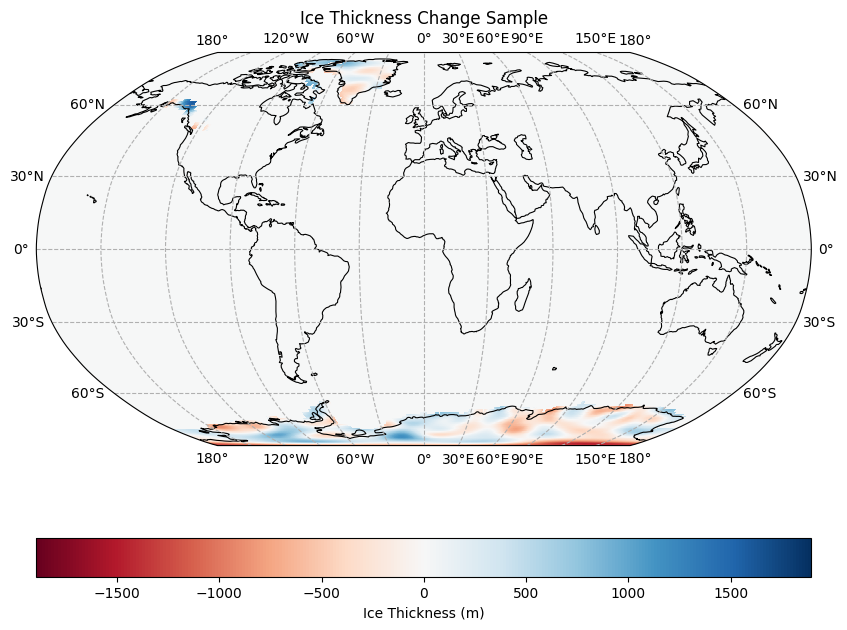

In [ ]:
ice_thickness_sample = (
    X.point_value_scaled_heat_kernel_gaussian_measure(
        scale=ice_thickness_length_scale,
        amplitude=ice_thickness_change_std,
    )
    .affine_mapping(operator=sl.ice_projection_operator(fp, X))
    .sample()
)

fig1, ax1, im1 = sl.plot(ice_thickness_sample, symmetric=True)
ax1.set_title("Ice Thickness Change Sample")
fig1.colorbar(im1, ax=ax1, orientation="horizontal", label="Ice Thickness (m)")

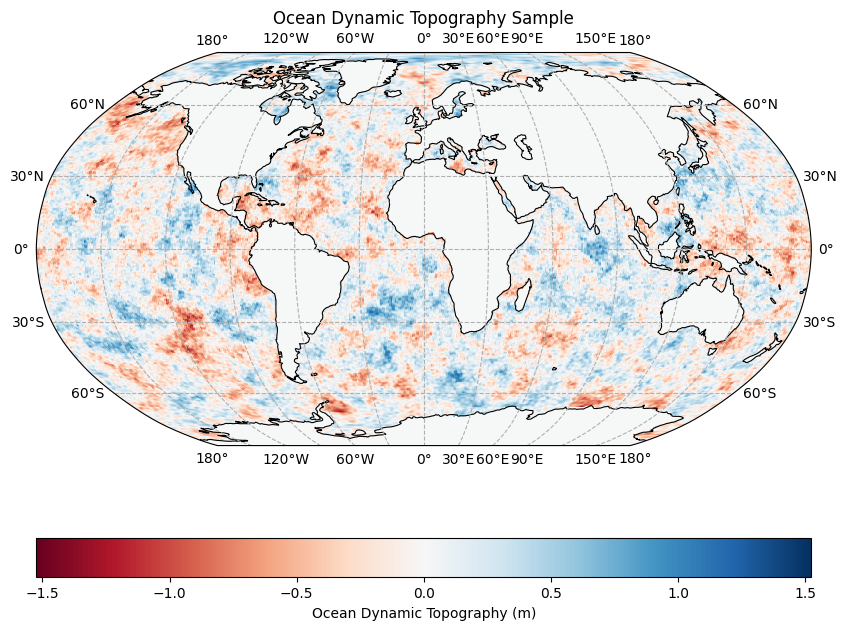

In [ ]:
ocean_dynamic_topography_sample = (
    X.point_value_scaled_sobolev_kernel_gaussian_measure(
        ocean_dynamic_topography_order,
        ocean_dynamic_topography_length_scales[0],
        ocean_dynamic_topography_amplitudes[0],
    )
    .affine_mapping(operator=sl.ocean_projection_operator(fp, X))
    .sample()
)

for ODT_LS, ODT_AMP in zip(
    ocean_dynamic_topography_length_scales[1:],
    ocean_dynamic_topography_amplitudes[1:],
):
    ocean_dynamic_topography_sample += (
        X.point_value_scaled_sobolev_kernel_gaussian_measure(
            ocean_dynamic_topography_order,
            ODT_LS,
            ODT_AMP,
        )
        .affine_mapping(operator=sl.ocean_projection_operator(fp, X))
        .sample()
    )


fig2, ax2, im2 = sl.plot(ocean_dynamic_topography_sample, symmetric=True)
ax2.set_title("Ocean Dynamic Topography Sample")
fig2.colorbar(
    im2, ax=ax2, orientation="horizontal", label="Ocean Dynamic Topography (m)"
)

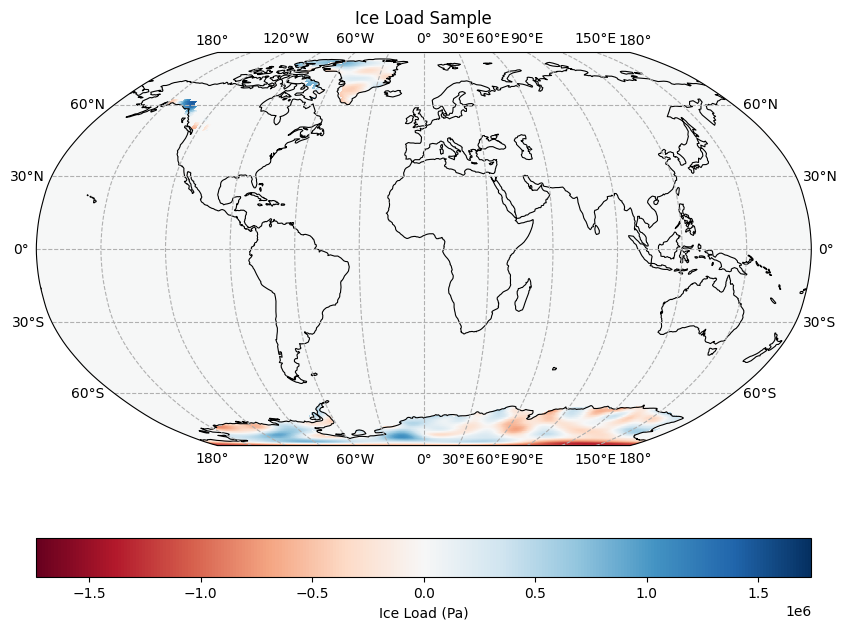

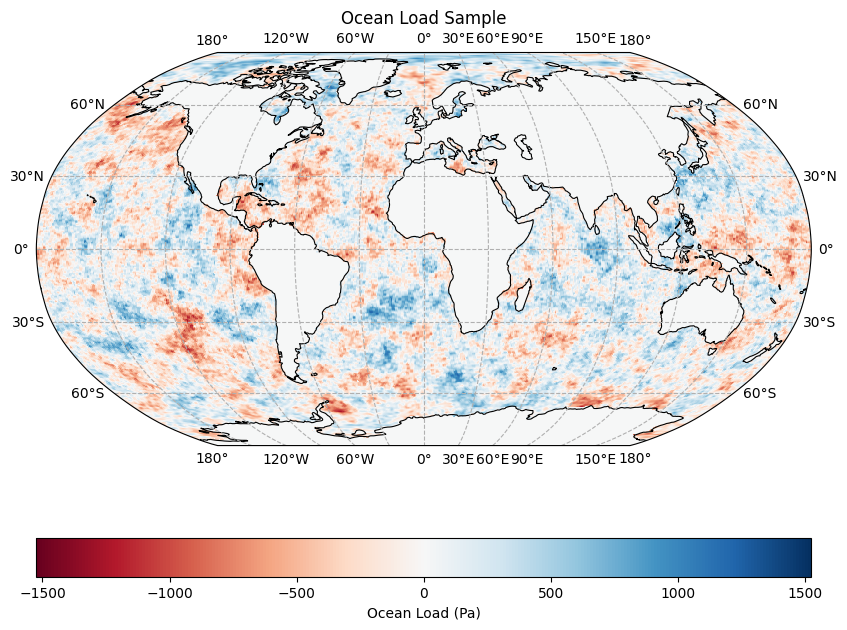

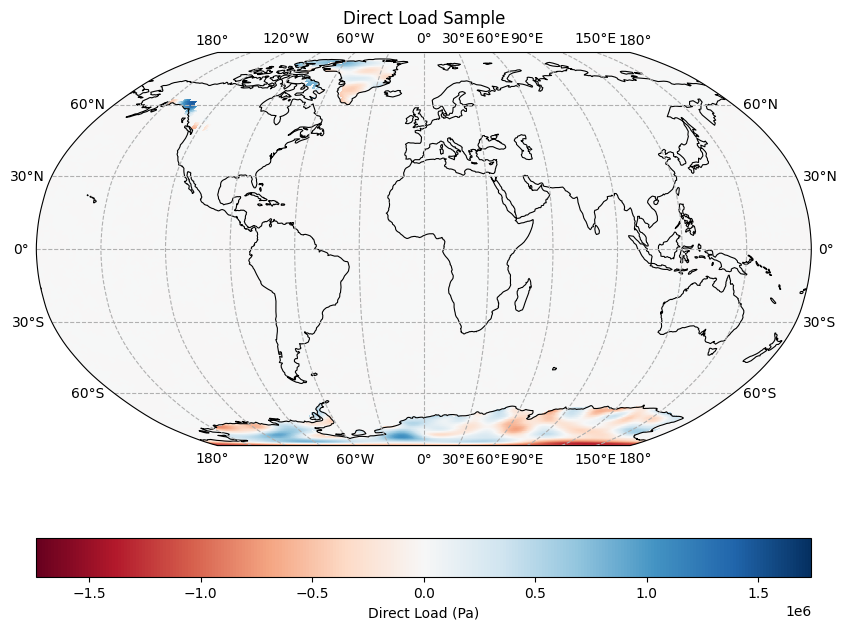

In [ ]:
ice_load = fp.direct_load_from_ice_thickness_change(ice_thickness_sample)
ocean_load = ocean_dynamic_topography_sample * fp.water_density

fig3, ax3, im3 = sl.plot(ice_load, symmetric=True)
ax3.set_title("Ice Load Sample")
fig3.colorbar(im3, ax=ax3, orientation="horizontal", label="Ice Load (Pa)")
fig4, ax4, im4 = sl.plot(ocean_load, symmetric=True)
ax4.set_title("Ocean Load Sample")
fig4.colorbar(im4, ax=ax4, orientation="horizontal", label="Ocean Load (Pa)")

direct_load = ice_load + ocean_load

fig5, ax5, im5 = sl.plot(direct_load, symmetric=True)
ax5.set_title("Direct Load Sample")
fig5.colorbar(im5, ax=ax5, orientation="horizontal", label="Direct Load (Pa)")

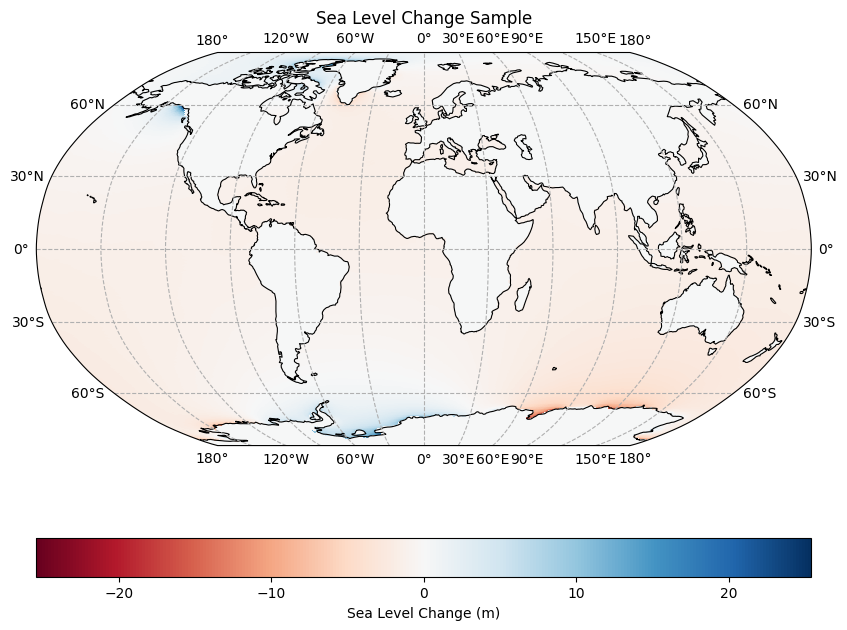

In [ ]:
sea_level_change, displacement, gravity_potential_change, angular_velocity_change = fp(
    direct_load=direct_load
)

fig6, ax6, im6 = sl.plot(sea_level_change * fp.ocean_function, symmetric=True)
ax6.set_title("Sea Level Change Sample")
fig6.colorbar(im6, ax=ax6, orientation="horizontal", label="Sea Level Change (m)")

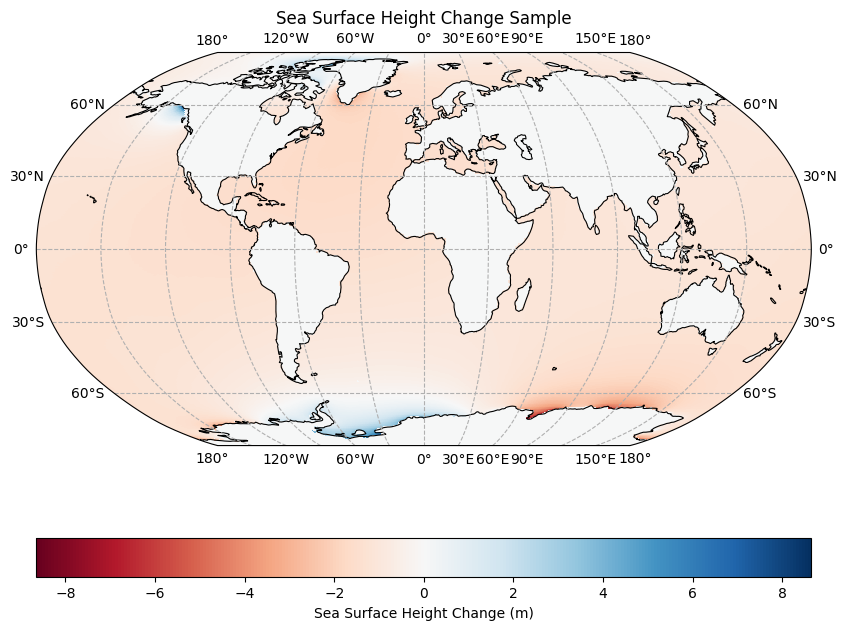

In [ ]:
sea_surface_height_change = (
    sea_level_change
    + displacement
    + (
        fp.centrifugal_potential_change(angular_velocity_change=angular_velocity_change)
        / GRAVITATIONAL_ACCELERATION
    )
)

fig7, ax7, im7 = sl.plot(sea_surface_height_change * fp.ocean_function, symmetric=True)
ax7.set_title("Sea Surface Height Change Sample")
fig7.colorbar(
    im7, ax=ax7, orientation="horizontal", label="Sea Surface Height Change (m)"
)

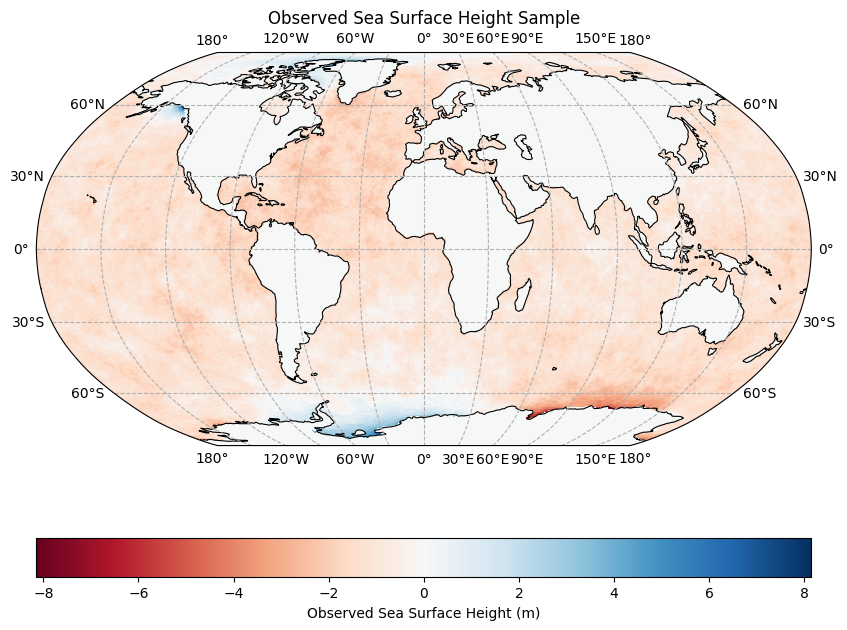

In [ ]:
observed_sea_surface = sea_surface_height_change + ocean_dynamic_topography_sample

fig8, ax8, im8 = sl.plot(observed_sea_surface * fp.ocean_function, symmetric=True)
ax8.set_title("Observed Sea Surface Height Sample")
fig8.colorbar(
    im8, ax=ax8, orientation="horizontal", label="Observed Sea Surface Height (m)"
)

In [ ]:
#  altimetry_projection = fp.altimetry_projection(
#                 latitude_min=-satellite_lat, latitude_max=satellite_lat, value=0
#             )

#             altimetry_projection_integral = fp.integrate(altimetry_projection)
#             altimetry_weighting_function = (
#                 altimetry_projection / altimetry_projection_integral
#             )

#             mean_sea_level_change_estimate = fp.integrate(
#                 altimetry_weighting_function * sea_surface_height_change_result
#             )


altimetry_weighting_function = fp.altimetry_projection(
    latitude_min=-66, latitude_max=66, value=0
) / fp.integrate(fp.altimetry_projection(latitude_min=-66, latitude_max=66, value=0))

gmsl_true = fp.integrate(sea_level_change * fp.ocean_function) / fp.integrate(
    fp.ocean_function
)
gmsl_estimated = fp.integrate(observed_sea_surface * fp.ocean_function) / fp.integrate(
    fp.ocean_function
)
gmsl_66_estimated = fp.integrate(
    altimetry_weighting_function * observed_sea_surface * fp.ocean_function
) / fp.integrate(altimetry_weighting_function * fp.ocean_function)
gmsl_ODT_estimated = fp.integrate(
    ocean_dynamic_topography_sample * fp.ocean_function
) / fp.integrate(fp.ocean_function)
gmsl_ODT_66_estimated = fp.integrate(
    altimetry_weighting_function * ocean_dynamic_topography_sample * fp.ocean_function
) / fp.integrate(altimetry_weighting_function * fp.ocean_function)

print(f"True GMSL Change: {gmsl_true:.4f} m")
print(f"Estimated GMSL Change: {gmsl_estimated:.4f} m")
print(f"66° GMSL Change: {gmsl_66_estimated:.4f} m")
print(f"ODT GMSL Change: {gmsl_ODT_estimated:.4f} m")
print(f"ODT 66° GMSL Change: {gmsl_ODT_66_estimated:.4f} m")

plt.show()

True GMSL Change: -1.2436 m
Estimated GMSL Change: -1.1630 m
66° GMSL Change: -1.2156 m
ODT GMSL Change: 0.0052 m
ODT 66° GMSL Change: 0.0018 m
